In [2]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import clone
import warnings
warnings.filterwarnings("ignore")



Evaluating Model: KNN
  Run 1: Acc=0.8687, Features=9
Features selected :[ 1  2 16 17 19 21 27 31 32] 
  Run 2: Acc=0.8586, Features=8
Features selected :[ 3  4  6 22 25 26 27 33] 
  Run 3: Acc=0.8586, Features=10
Features selected :[ 1  2  3  6 12 16 19 20 22 35] 
  Run 4: Acc=0.8687, Features=8
Features selected :[ 6 10 13 20 21 23 26 33] 
  Run 5: Acc=0.8485, Features=11
Features selected :[ 3  5  6 10 14 18 21 23 25 27 31] 
  Run 6: Acc=0.8384, Features=9
Features selected :[ 3  4  6 10 19 21 23 25 32] 
  Run 7: Acc=0.8081, Features=8
Features selected :[ 3  5  9 20 23 24 26 28] 
  Run 8: Acc=0.8182, Features=10
Features selected :[ 3  5  8 10 21 24 25 27 33 34] 
  Run 9: Acc=0.8283, Features=8
Features selected :[ 3 11 15 25 26 30 31 33] 
  Run 10: Acc=0.8687, Features=8
Features selected :[ 5 11 20 21 25 28 30 32] 
  Accuracy without FS: 82.83 %

Evaluating Model: NB
  Run 1: Acc=0.8384, Features=11
Features selected :[ 3  4  7  9 11 14 15 22 27 28 33] 
  Run 2: Acc=0.8485, Feat

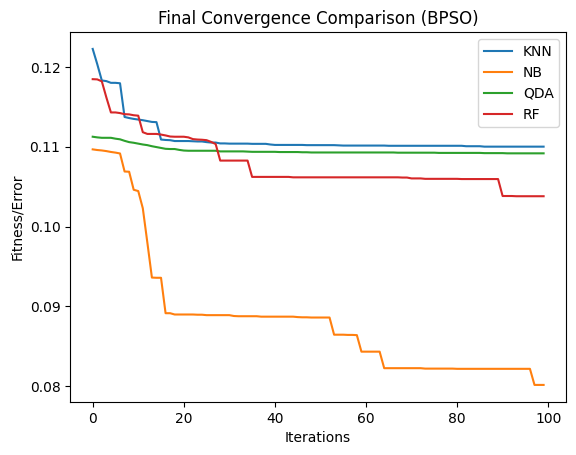


  SUMMARY  (averaged over 10 independent runs)

  --- Without Feature Selection ---
  Accuracy  : 84.09 %
  Precision : 0.7782
  Recall    : 0.8409
  F1-Score  : 0.8049

  Avg Execution Time : 22.4006 s
  Avg Memory Used    : 0.1145 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  84.65%   0.7765  0.8465 0.8046       8.9    75.95%
   NB  84.55%   0.8247  0.8455 0.8326       9.9    73.24%
  QDA  85.76%   0.7533  0.8576 0.8021       5.8    84.32%
   RF  84.95%   0.7624  0.8495 0.8011       9.8    73.51%


In [2]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ============================================================
# DATA LOADING & PREPROCESSING
# ============================================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-CM1.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
if 'id' in df.columns: df = df.drop(columns=['id'])

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

training_data = pd.DataFrame(X_train_scaled)
testing_data = pd.DataFrame(X_test_scaled)
training_label = y_train.reset_index(drop=True)
testing_label = y_test.reset_index(drop=True)

# ============================================================
# BPSO PARAMETERS
# ============================================================
NP = 10 
D = training_data.shape[1]
max_itr = 100
wmax = 0.9
wmin = 0.4
c1 = 2
c2 = 2
Vmax = D - 1
Vmin = -Vmax
alpha_weight = 0.99 

# ============================================================
# UTILITIES
# ============================================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def FitnessFunction(selected_indices, model_obj):
    if len(selected_indices) == 0:
        return 1.0
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        training_data.iloc[:, selected_indices], 
        training_label, 
        test_size=0.2, 
        random_state=42, 
        stratify=training_label
    )
    
    try:
        clf = clone(model_obj)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        error = 1 - accuracy_score(y_val, preds)
        feat_penalty = len(selected_indices) / D
        return alpha_weight * error + (1 - alpha_weight) * feat_penalty
    except:
        return 1.0

# ============================================================
# BPSO
# ============================================================
def BPSO_SFP(model_obj):
    X = np.random.randint(0, 2, (NP, D))
    V = np.random.uniform(Vmin, Vmax, (NP, D))
    fit = np.array([FitnessFunction(np.where(X[i] == 1)[0], model_obj) for i in range(NP)])
    pbest = X.copy()
    Pfit = fit.copy()
    gbest = X[np.argmin(fit)].copy()
    Gfit = np.min(fit)
    convergence_curve = []
    
    for epoch in range(max_itr):
        w = wmax - (wmax - wmin) * (epoch / max_itr)
        for i in range(NP):
            r1, r2 = random.random(), random.random()
            V[i] = (w * V[i] + c1 * r1 * (pbest[i] - X[i]) + c2 * r2 * (gbest - X[i]))
            V[i] = np.clip(V[i], Vmin, Vmax)
            for j in range(D):
                X[i, j] = 1 if sigmoid(V[i, j]) > random.random() else 0

            curr_idx = np.where(X[i] == 1)[0]
            curr_fit = FitnessFunction(curr_idx, model_obj)

            if curr_fit < Pfit[i]:
                pbest[i] = X[i].copy()
                Pfit[i] = curr_fit

            if Pfit[i] < Gfit:
                gbest = pbest[i].copy()
                Gfit = Pfit[i]

        convergence_curve.append(Gfit)

    return gbest, convergence_curve

# ============================================================
# MAIN LOOP
# ============================================================
models_dict = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS   = []
average_precision_without_FS  = []
average_recall_without_FS     = []
average_f1_without_FS         = []

for model_name, model_obj in models_dict.items():
    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []
    
    for r in range(1, 11): 
        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        best_mask, curve = BPSO_SFP(model_obj)
           
        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2
    
        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_mask == 1)[0]
        if len(Sf_idx) == 0: Sf_idx = np.array([np.random.randint(0, D)])
        
        clf = clone(model_obj)
        clf.fit(training_data.iloc[:, Sf_idx], training_label)
        pred = clf.predict(testing_data.iloc[:, Sf_idx])
        y_true = testing_label
        
        acc_list.append(accuracy_score(y_true, pred))
        prec_list.append(precision_score(y_true, pred, average='weighted', zero_division=0))
        rec_list.append(recall_score(y_true, pred, average='weighted', zero_division=0))
        f1_list.append(f1_score(y_true, pred, average='weighted', zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(curve)
        
        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f'Features selected :{Sf_idx} ')

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(training_data, training_label)
    pred_no_fs = clf_nofs.predict(testing_data)

    acc_no = accuracy_score(testing_label, pred_no_fs) * 100
    print(f"  Accuracy without FS: {acc_no:.2f} %")
    
    average_accuracy_without_FS.append(acc_no)
    average_precision_without_FS.append(precision_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(testing_label, pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (BPSO)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  --- Without Feature Selection ---")
print(f"  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.7679, Features=9
Features selected :[ 7  8 10 12 13 16 17 18 20] 
  Run 2: Acc=0.7602, Features=6
Features selected :[ 7  9 11 13 14 17] 
  Run 3: Acc=0.7679, Features=9
Features selected :[ 7  8 10 12 13 16 17 18 20] 
  Run 4: Acc=0.7649, Features=9
Features selected :[ 0  2  5  8 10 11 16 18 20] 
  Run 5: Acc=0.7803, Features=1
Features selected :[5] 
  Run 6: Acc=0.7666, Features=9
Features selected :[ 0  5  9 13 14 15 16 17 19] 
  Run 7: Acc=0.7657, Features=8
Features selected :[ 0  3 11 12 14 16 17 18] 
  Run 8: Acc=0.7478, Features=4
Features selected :[ 0  5 18 19] 
  Run 9: Acc=0.7525, Features=7
Features selected :[ 0  7 10 13 14 19 20] 
  Run 10: Acc=0.7572, Features=6
Features selected :[ 0  1  3  8 12 17] 
  Accuracy without FS: 76.96 %

Evaluating Model: NB
  Run 1: Acc=0.7782, Features=4
Features selected :[ 0  8 14 19] 
  Run 2: Acc=0.7803, Features=6
Features selected :[ 0  8 10 14 15 19] 
  Run 3: Acc=0.7824, Features=6
Features s

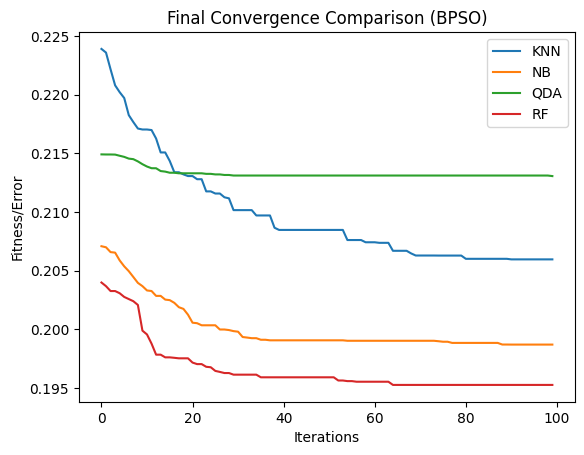


  SUMMARY  (averaged over 10 independent runs)

  --- Without Feature Selection ---
  Accuracy  : 77.78 %
  Precision : 0.7555
  Recall    : 0.7778
  F1-Score  : 0.7259

  Avg Execution Time : 51.6764 s
  Avg Memory Used    : 0.6386 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  76.31%   0.7195  0.7631 0.7299       6.8    67.62%
   NB  78.16%   0.7285  0.7816 0.7262       5.1    75.71%
  QDA  78.50%   0.6162  0.7850 0.6905       1.1    94.76%
   RF  77.63%   0.7310  0.7763 0.7379       9.9    52.86%


In [3]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ============================================================
# DATA LOADING & PREPROCESSING
# ============================================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-JM1.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
if 'id' in df.columns: df = df.drop(columns=['id'])

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

training_data = pd.DataFrame(X_train_scaled)
testing_data = pd.DataFrame(X_test_scaled)
training_label = y_train.reset_index(drop=True)
testing_label = y_test.reset_index(drop=True)

# ============================================================
# BPSO PARAMETERS
# ============================================================
NP = 10 
D = training_data.shape[1]
max_itr = 100
wmax = 0.9
wmin = 0.4
c1 = 2
c2 = 2
Vmax = D - 1
Vmin = -Vmax
alpha_weight = 0.99 

# ============================================================
# UTILITIES
# ============================================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def FitnessFunction(selected_indices, model_obj):
    if len(selected_indices) == 0:
        return 1.0
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        training_data.iloc[:, selected_indices], 
        training_label, 
        test_size=0.2, 
        random_state=42, 
        stratify=training_label
    )
    
    try:
        clf = clone(model_obj)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        error = 1 - accuracy_score(y_val, preds)
        feat_penalty = len(selected_indices) / D
        return alpha_weight * error + (1 - alpha_weight) * feat_penalty
    except:
        return 1.0

# ============================================================
# BPSO
# ============================================================
def BPSO_SFP(model_obj):
    X = np.random.randint(0, 2, (NP, D))
    V = np.random.uniform(Vmin, Vmax, (NP, D))
    fit = np.array([FitnessFunction(np.where(X[i] == 1)[0], model_obj) for i in range(NP)])
    pbest = X.copy()
    Pfit = fit.copy()
    gbest = X[np.argmin(fit)].copy()
    Gfit = np.min(fit)
    convergence_curve = []
    
    for epoch in range(max_itr):
        w = wmax - (wmax - wmin) * (epoch / max_itr)
        for i in range(NP):
            r1, r2 = random.random(), random.random()
            V[i] = (w * V[i] + c1 * r1 * (pbest[i] - X[i]) + c2 * r2 * (gbest - X[i]))
            V[i] = np.clip(V[i], Vmin, Vmax)
            for j in range(D):
                X[i, j] = 1 if sigmoid(V[i, j]) > random.random() else 0

            curr_idx = np.where(X[i] == 1)[0]
            curr_fit = FitnessFunction(curr_idx, model_obj)

            if curr_fit < Pfit[i]:
                pbest[i] = X[i].copy()
                Pfit[i] = curr_fit

            if Pfit[i] < Gfit:
                gbest = pbest[i].copy()
                Gfit = Pfit[i]

        convergence_curve.append(Gfit)

    return gbest, convergence_curve

# ============================================================
# MAIN LOOP
# ============================================================
models_dict = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS   = []
average_precision_without_FS  = []
average_recall_without_FS     = []
average_f1_without_FS         = []

for model_name, model_obj in models_dict.items():
    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []
    
    for r in range(1, 11): 
        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        best_mask, curve = BPSO_SFP(model_obj)
           
        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2
    
        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_mask == 1)[0]
        if len(Sf_idx) == 0: Sf_idx = np.array([np.random.randint(0, D)])
        
        clf = clone(model_obj)
        clf.fit(training_data.iloc[:, Sf_idx], training_label)
        pred = clf.predict(testing_data.iloc[:, Sf_idx])
        y_true = testing_label
        
        acc_list.append(accuracy_score(y_true, pred))
        prec_list.append(precision_score(y_true, pred, average='weighted', zero_division=0))
        rec_list.append(recall_score(y_true, pred, average='weighted', zero_division=0))
        f1_list.append(f1_score(y_true, pred, average='weighted', zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(curve)
        
        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f'Features selected :{Sf_idx} ')

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(training_data, training_label)
    pred_no_fs = clf_nofs.predict(testing_data)

    acc_no = accuracy_score(testing_label, pred_no_fs) * 100
    print(f"  Accuracy without FS: {acc_no:.2f} %")
    
    average_accuracy_without_FS.append(acc_no)
    average_precision_without_FS.append(precision_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(testing_label, pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (BPSO)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  --- Without Feature Selection ---")
print(f"  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.7070, Features=11
Features selected :[ 0  2  3  4  5  8 14 16 17 18 20] 
  Run 2: Acc=0.7268, Features=9
Features selected :[ 0  1  8 10 11 15 17 18 20] 
  Run 3: Acc=0.7099, Features=8
Features selected :[ 1  5  8  9 10 13 15 18] 
  Run 4: Acc=0.7239, Features=11
Features selected :[ 0  1  3  5  8 10 11 13 14 17 18] 
  Run 5: Acc=0.7183, Features=8
Features selected :[ 2  4  7  8 16 17 18 20] 
  Run 6: Acc=0.7296, Features=10
Features selected :[ 0  1  2  8 10 11 14 15 18 20] 
  Run 7: Acc=0.7268, Features=7
Features selected :[ 2  4  5  8 12 18 20] 
  Run 8: Acc=0.7014, Features=10
Features selected :[ 0  1  3  5  8 10 16 17 18 20] 
  Run 9: Acc=0.7042, Features=11
Features selected :[ 1  3  5  8  9 13 14 15 16 18 20] 
  Run 10: Acc=0.7239, Features=9
Features selected :[ 0  1  8 10 14 15 17 18 20] 
  Accuracy without FS: 72.68 %

Evaluating Model: NB
  Run 1: Acc=0.7324, Features=6
Features selected :[ 0  3  8 10 14 16] 
  Run 2: Acc=0.7268, Fea

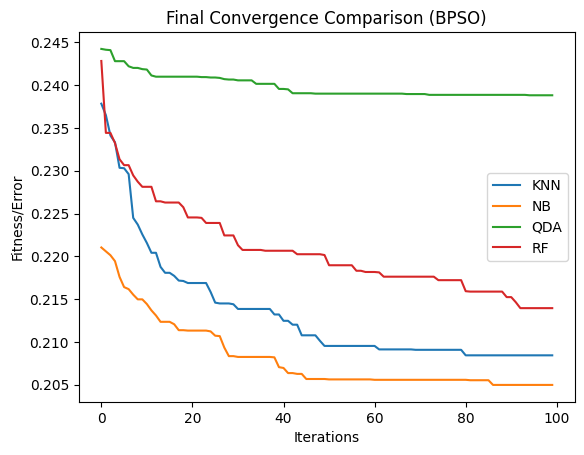


  SUMMARY  (averaged over 10 independent runs)

  --- Without Feature Selection ---
  Accuracy  : 72.82 %
  Precision : 0.6915
  Recall    : 0.7282
  F1-Score  : 0.6899

  Avg Execution Time : 26.1746 s
  Avg Memory Used    : 0.0005 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  71.72%   0.6797  0.7172 0.6878       9.4    55.24%
   NB  73.49%   0.6983  0.7349 0.6993       5.9    71.90%
  QDA  74.20%   0.7027  0.7420 0.6609       6.8    67.62%
   RF  73.10%   0.6974  0.7310 0.7019       9.7    53.81%


In [4]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ============================================================
# DATA LOADING & PREPROCESSING
# ============================================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-KC1.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
if 'id' in df.columns: df = df.drop(columns=['id'])

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

training_data = pd.DataFrame(X_train_scaled)
testing_data = pd.DataFrame(X_test_scaled)
training_label = y_train.reset_index(drop=True)
testing_label = y_test.reset_index(drop=True)

# ============================================================
# BPSO PARAMETERS
# ============================================================
NP = 10 
D = training_data.shape[1]
max_itr = 100
wmax = 0.9
wmin = 0.4
c1 = 2
c2 = 2
Vmax = D - 1
Vmin = -Vmax
alpha_weight = 0.99 

# ============================================================
# UTILITIES
# ============================================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def FitnessFunction(selected_indices, model_obj):
    if len(selected_indices) == 0:
        return 1.0
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        training_data.iloc[:, selected_indices], 
        training_label, 
        test_size=0.2, 
        random_state=42, 
        stratify=training_label
    )
    
    try:
        clf = clone(model_obj)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        error = 1 - accuracy_score(y_val, preds)
        feat_penalty = len(selected_indices) / D
        return alpha_weight * error + (1 - alpha_weight) * feat_penalty
    except:
        return 1.0

# ============================================================
# BPSO
# ============================================================
def BPSO_SFP(model_obj):
    X = np.random.randint(0, 2, (NP, D))
    V = np.random.uniform(Vmin, Vmax, (NP, D))
    fit = np.array([FitnessFunction(np.where(X[i] == 1)[0], model_obj) for i in range(NP)])
    pbest = X.copy()
    Pfit = fit.copy()
    gbest = X[np.argmin(fit)].copy()
    Gfit = np.min(fit)
    convergence_curve = []
    
    for epoch in range(max_itr):
        w = wmax - (wmax - wmin) * (epoch / max_itr)
        for i in range(NP):
            r1, r2 = random.random(), random.random()
            V[i] = (w * V[i] + c1 * r1 * (pbest[i] - X[i]) + c2 * r2 * (gbest - X[i]))
            V[i] = np.clip(V[i], Vmin, Vmax)
            for j in range(D):
                X[i, j] = 1 if sigmoid(V[i, j]) > random.random() else 0

            curr_idx = np.where(X[i] == 1)[0]
            curr_fit = FitnessFunction(curr_idx, model_obj)

            if curr_fit < Pfit[i]:
                pbest[i] = X[i].copy()
                Pfit[i] = curr_fit

            if Pfit[i] < Gfit:
                gbest = pbest[i].copy()
                Gfit = Pfit[i]

        convergence_curve.append(Gfit)

    return gbest, convergence_curve

# ============================================================
# MAIN LOOP
# ============================================================
models_dict = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS   = []
average_precision_without_FS  = []
average_recall_without_FS     = []
average_f1_without_FS         = []

for model_name, model_obj in models_dict.items():
    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []
    
    for r in range(1, 11): 
        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        best_mask, curve = BPSO_SFP(model_obj)
           
        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2
    
        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_mask == 1)[0]
        if len(Sf_idx) == 0: Sf_idx = np.array([np.random.randint(0, D)])
        
        clf = clone(model_obj)
        clf.fit(training_data.iloc[:, Sf_idx], training_label)
        pred = clf.predict(testing_data.iloc[:, Sf_idx])
        y_true = testing_label
        
        acc_list.append(accuracy_score(y_true, pred))
        prec_list.append(precision_score(y_true, pred, average='weighted', zero_division=0))
        rec_list.append(recall_score(y_true, pred, average='weighted', zero_division=0))
        f1_list.append(f1_score(y_true, pred, average='weighted', zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(curve)
        
        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f'Features selected :{Sf_idx} ')

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(training_data, training_label)
    pred_no_fs = clf_nofs.predict(testing_data)

    acc_no = accuracy_score(testing_label, pred_no_fs) * 100
    print(f"  Accuracy without FS: {acc_no:.2f} %")
    
    average_accuracy_without_FS.append(acc_no)
    average_precision_without_FS.append(precision_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(testing_label, pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (BPSO)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  --- Without Feature Selection ---")
print(f"  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.7797, Features=14
Features selected :[ 0  3  4  5  8 11 12 13 14 24 25 28 31 34] 
  Run 2: Acc=0.7966, Features=10
Features selected :[ 0  3  4  5  8 12 14 15 28 29] 
  Run 3: Acc=0.7966, Features=12
Features selected :[ 1  3  7  9 11 13 16 17 18 27 32 34] 
  Run 4: Acc=0.7458, Features=15
Features selected :[ 0  2  3  4 10 11 14 18 19 22 24 26 29 30 31] 
  Run 5: Acc=0.7627, Features=9
Features selected :[ 0  1  2  4  5  6 13 18 21] 
  Run 6: Acc=0.8136, Features=10
Features selected :[ 0  3  5  8 10 12 15 28 35 36] 
  Run 7: Acc=0.7627, Features=16
Features selected :[ 0  2  3  4  5  8 10 11 14 18 19 21 26 28 31 34] 
  Run 8: Acc=0.7458, Features=9
Features selected :[ 0  2  4  9 17 18 19 29 35] 
  Run 9: Acc=0.7966, Features=7
Features selected :[ 3 11 14 16 25 27 34] 
  Run 10: Acc=0.7627, Features=19
Features selected :[ 0  2  3  4  6  7  8  9 11 14 15 18 21 22 25 28 29 31 38] 
  Accuracy without FS: 74.58 %

Evaluating Model: NB
  Run 1: Acc=

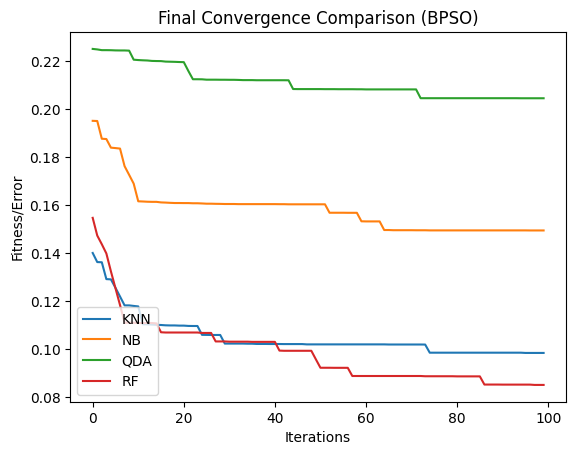


  SUMMARY  (averaged over 10 independent runs)

  --- Without Feature Selection ---
  Accuracy  : 77.97 %
  Precision : 0.7053
  Recall    : 0.7797
  F1-Score  : 0.7365

  Avg Execution Time : 21.3031 s
  Avg Memory Used    : 0.0020 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  77.63%   0.6902  0.7763 0.7270      12.1    68.97%
   NB  79.32%   0.7502  0.7932 0.7621      11.0    71.79%
  QDA  80.51%   0.7157  0.8051 0.7411      11.4    70.77%
   RF  77.63%   0.7159  0.7763 0.7386      17.3    55.64%


In [5]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ============================================================
# DATA LOADING & PREPROCESSING
# ============================================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-KC3.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
if 'id' in df.columns: df = df.drop(columns=['id'])

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

training_data = pd.DataFrame(X_train_scaled)
testing_data = pd.DataFrame(X_test_scaled)
training_label = y_train.reset_index(drop=True)
testing_label = y_test.reset_index(drop=True)

# ============================================================
# BPSO PARAMETERS
# ============================================================
NP = 10 
D = training_data.shape[1]
max_itr = 100
wmax = 0.9
wmin = 0.4
c1 = 2
c2 = 2
Vmax = D - 1
Vmin = -Vmax
alpha_weight = 0.99 

# ============================================================
# UTILITIES
# ============================================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def FitnessFunction(selected_indices, model_obj):
    if len(selected_indices) == 0:
        return 1.0
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        training_data.iloc[:, selected_indices], 
        training_label, 
        test_size=0.2, 
        random_state=42, 
        stratify=training_label
    )
    
    try:
        clf = clone(model_obj)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        error = 1 - accuracy_score(y_val, preds)
        feat_penalty = len(selected_indices) / D
        return alpha_weight * error + (1 - alpha_weight) * feat_penalty
    except:
        return 1.0

# ============================================================
# BPSO
# ============================================================
def BPSO_SFP(model_obj):
    X = np.random.randint(0, 2, (NP, D))
    V = np.random.uniform(Vmin, Vmax, (NP, D))
    fit = np.array([FitnessFunction(np.where(X[i] == 1)[0], model_obj) for i in range(NP)])
    pbest = X.copy()
    Pfit = fit.copy()
    gbest = X[np.argmin(fit)].copy()
    Gfit = np.min(fit)
    convergence_curve = []
    
    for epoch in range(max_itr):
        w = wmax - (wmax - wmin) * (epoch / max_itr)
        for i in range(NP):
            r1, r2 = random.random(), random.random()
            V[i] = (w * V[i] + c1 * r1 * (pbest[i] - X[i]) + c2 * r2 * (gbest - X[i]))
            V[i] = np.clip(V[i], Vmin, Vmax)
            for j in range(D):
                X[i, j] = 1 if sigmoid(V[i, j]) > random.random() else 0

            curr_idx = np.where(X[i] == 1)[0]
            curr_fit = FitnessFunction(curr_idx, model_obj)

            if curr_fit < Pfit[i]:
                pbest[i] = X[i].copy()
                Pfit[i] = curr_fit

            if Pfit[i] < Gfit:
                gbest = pbest[i].copy()
                Gfit = Pfit[i]

        convergence_curve.append(Gfit)

    return gbest, convergence_curve

# ============================================================
# MAIN LOOP
# ============================================================
models_dict = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS   = []
average_precision_without_FS  = []
average_recall_without_FS     = []
average_f1_without_FS         = []

for model_name, model_obj in models_dict.items():
    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []
    
    for r in range(1, 11): 
        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        best_mask, curve = BPSO_SFP(model_obj)
           
        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2
    
        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_mask == 1)[0]
        if len(Sf_idx) == 0: Sf_idx = np.array([np.random.randint(0, D)])
        
        clf = clone(model_obj)
        clf.fit(training_data.iloc[:, Sf_idx], training_label)
        pred = clf.predict(testing_data.iloc[:, Sf_idx])
        y_true = testing_label
        
        acc_list.append(accuracy_score(y_true, pred))
        prec_list.append(precision_score(y_true, pred, average='weighted', zero_division=0))
        rec_list.append(recall_score(y_true, pred, average='weighted', zero_division=0))
        f1_list.append(f1_score(y_true, pred, average='weighted', zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(curve)
        
        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f'Features selected :{Sf_idx} ')

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(training_data, training_label)
    pred_no_fs = clf_nofs.predict(testing_data)

    acc_no = accuracy_score(testing_label, pred_no_fs) * 100
    print(f"  Accuracy without FS: {acc_no:.2f} %")
    
    average_accuracy_without_FS.append(acc_no)
    average_precision_without_FS.append(precision_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(testing_label, pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (BPSO)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  --- Without Feature Selection ---")
print(f"  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.9765, Features=11
Features selected :[ 0  2  5 10 12 14 21 27 28 36 37] 
  Run 2: Acc=0.9732, Features=13
Features selected :[ 0  2  7  9 12 22 24 25 28 30 33 36 37] 
  Run 3: Acc=0.9715, Features=11
Features selected :[ 0  2  3  9 10 12 16 28 30 35 36] 
  Run 4: Acc=0.9732, Features=11
Features selected :[ 2  3 10 12 16 19 23 24 30 35 37] 
  Run 5: Acc=0.9732, Features=15
Features selected :[ 0  1  2  7 12 14 15 19 21 28 30 32 33 34 36] 
  Run 6: Acc=0.9732, Features=12
Features selected :[ 1  6  7  9 12 19 23 25 28 30 36 37] 
  Run 7: Acc=0.9698, Features=13
Features selected :[ 0  1  2  6 12 19 22 23 28 32 33 36 37] 
  Run 8: Acc=0.9732, Features=10
Features selected :[ 1  2  6  8 12 14 22 24 25 29] 
  Run 9: Acc=0.9665, Features=11
Features selected :[ 0 10 12 15 17 21 22 27 28 32 35] 
  Run 10: Acc=0.9732, Features=11
Features selected :[12 14 16 17 19 25 27 29 31 33 37] 
  Accuracy without FS: 97.65 %

Evaluating Model: NB
  Run 1: Acc=0.9682

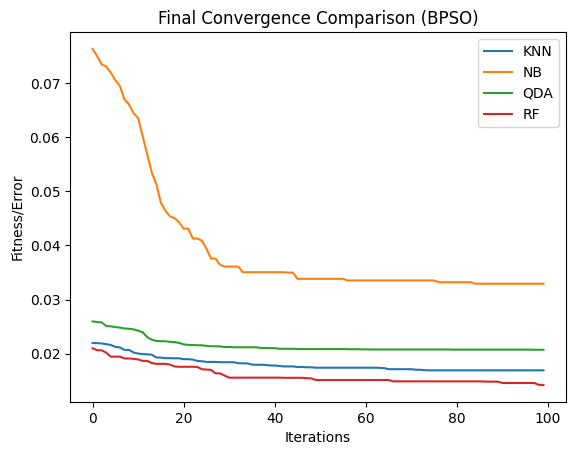


  SUMMARY  (averaged over 10 independent runs)

  --- Without Feature Selection ---
  Accuracy  : 95.77 %
  Precision : 0.9610
  Recall    : 0.9577
  F1-Score  : 0.9579

  Avg Execution Time : 28.4892 s
  Avg Memory Used    : 0.0486 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  97.24%   0.9599  0.9724 0.9651      11.8    68.95%
   NB  96.42%   0.9554  0.9642 0.9595       9.2    75.79%
  QDA  97.65%   0.9536  0.9765 0.9650      11.4    70.00%
   RF  97.19%   0.9636  0.9719 0.9671      13.7    63.95%


In [6]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ============================================================
# DATA LOADING & PREPROCESSING
# ============================================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-MC1.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
if 'id' in df.columns: df = df.drop(columns=['id'])

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

training_data = pd.DataFrame(X_train_scaled)
testing_data = pd.DataFrame(X_test_scaled)
training_label = y_train.reset_index(drop=True)
testing_label = y_test.reset_index(drop=True)

# ============================================================
# BPSO PARAMETERS
# ============================================================
NP = 10 
D = training_data.shape[1]
max_itr = 100
wmax = 0.9
wmin = 0.4
c1 = 2
c2 = 2
Vmax = D - 1
Vmin = -Vmax
alpha_weight = 0.99 

# ============================================================
# UTILITIES
# ============================================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def FitnessFunction(selected_indices, model_obj):
    if len(selected_indices) == 0:
        return 1.0
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        training_data.iloc[:, selected_indices], 
        training_label, 
        test_size=0.2, 
        random_state=42, 
        stratify=training_label
    )
    
    try:
        clf = clone(model_obj)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        error = 1 - accuracy_score(y_val, preds)
        feat_penalty = len(selected_indices) / D
        return alpha_weight * error + (1 - alpha_weight) * feat_penalty
    except:
        return 1.0

# ============================================================
# BPSO
# ============================================================
def BPSO_SFP(model_obj):
    X = np.random.randint(0, 2, (NP, D))
    V = np.random.uniform(Vmin, Vmax, (NP, D))
    fit = np.array([FitnessFunction(np.where(X[i] == 1)[0], model_obj) for i in range(NP)])
    pbest = X.copy()
    Pfit = fit.copy()
    gbest = X[np.argmin(fit)].copy()
    Gfit = np.min(fit)
    convergence_curve = []
    
    for epoch in range(max_itr):
        w = wmax - (wmax - wmin) * (epoch / max_itr)
        for i in range(NP):
            r1, r2 = random.random(), random.random()
            V[i] = (w * V[i] + c1 * r1 * (pbest[i] - X[i]) + c2 * r2 * (gbest - X[i]))
            V[i] = np.clip(V[i], Vmin, Vmax)
            for j in range(D):
                X[i, j] = 1 if sigmoid(V[i, j]) > random.random() else 0

            curr_idx = np.where(X[i] == 1)[0]
            curr_fit = FitnessFunction(curr_idx, model_obj)

            if curr_fit < Pfit[i]:
                pbest[i] = X[i].copy()
                Pfit[i] = curr_fit

            if Pfit[i] < Gfit:
                gbest = pbest[i].copy()
                Gfit = Pfit[i]

        convergence_curve.append(Gfit)

    return gbest, convergence_curve

# ============================================================
# MAIN LOOP
# ============================================================
models_dict = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS   = []
average_precision_without_FS  = []
average_recall_without_FS     = []
average_f1_without_FS         = []

for model_name, model_obj in models_dict.items():
    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []
    
    for r in range(1, 11): 
        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        best_mask, curve = BPSO_SFP(model_obj)
           
        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2
    
        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_mask == 1)[0]
        if len(Sf_idx) == 0: Sf_idx = np.array([np.random.randint(0, D)])
        
        clf = clone(model_obj)
        clf.fit(training_data.iloc[:, Sf_idx], training_label)
        pred = clf.predict(testing_data.iloc[:, Sf_idx])
        y_true = testing_label
        
        acc_list.append(accuracy_score(y_true, pred))
        prec_list.append(precision_score(y_true, pred, average='weighted', zero_division=0))
        rec_list.append(recall_score(y_true, pred, average='weighted', zero_division=0))
        f1_list.append(f1_score(y_true, pred, average='weighted', zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(curve)
        
        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f'Features selected :{Sf_idx} ')

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(training_data, training_label)
    pred_no_fs = clf_nofs.predict(testing_data)

    acc_no = accuracy_score(testing_label, pred_no_fs) * 100
    print(f"  Accuracy without FS: {acc_no:.2f} %")
    
    average_accuracy_without_FS.append(acc_no)
    average_precision_without_FS.append(precision_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(testing_label, pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (BPSO)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  --- Without Feature Selection ---")
print(f"  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.6053, Features=16
Features selected :[ 1  7 12 14 17 19 20 24 25 26 27 28 29 33 36 37] 
  Run 2: Acc=0.5789, Features=14
Features selected :[ 0  3  7  8 14 15 19 20 23 26 27 30 37 38] 
  Run 3: Acc=0.6053, Features=15
Features selected :[ 0  5  6 12 14 19 20 23 24 26 27 31 32 37 38] 
  Run 4: Acc=0.6053, Features=12
Features selected :[ 0  1  8 14 18 20 24 26 34 35 37 38] 
  Run 5: Acc=0.5789, Features=13
Features selected :[ 0  1  7  8 12 14 15 20 21 29 33 34 37] 
  Run 6: Acc=0.6053, Features=9
Features selected :[ 1  5 10 14 19 21 25 26 28] 
  Run 7: Acc=0.6316, Features=13
Features selected :[10 14 15 16 19 21 22 24 26 27 31 32 37] 
  Run 8: Acc=0.6842, Features=14
Features selected :[ 1  2  4 12 13 14 18 20 21 25 26 27 34 35] 
  Run 9: Acc=0.5526, Features=19
Features selected :[ 1  2  3  6  7 13 14 15 17 19 20 22 25 26 27 29 32 37 38] 
  Run 10: Acc=0.5526, Features=16
Features selected :[ 0  1  7 10 14 15 19 21 22 23 27 34 35 36 37 38] 
  Ac

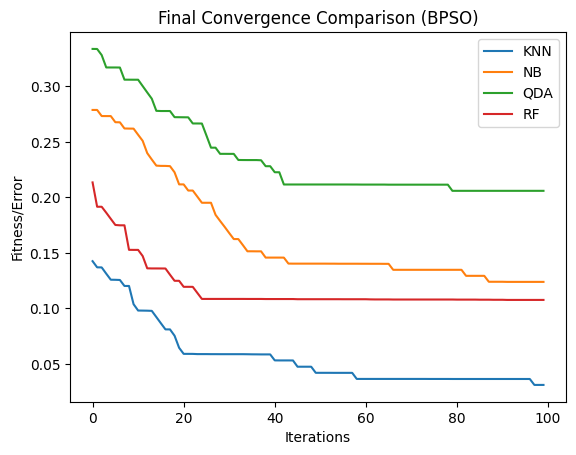


  SUMMARY  (averaged over 10 independent runs)

  --- Without Feature Selection ---
  Accuracy  : 70.39 %
  Precision : 0.7235
  Recall    : 0.7039
  F1-Score  : 0.6586

  Avg Execution Time : 24.5397 s
  Avg Memory Used    : 0.1157 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  60.00%   0.5816  0.6000 0.5874      14.1    63.85%
   NB  68.16%   0.6724  0.6816 0.6745      11.3    71.03%
  QDA  68.95%   0.6832  0.6895 0.6498       9.3    76.15%
   RF  61.05%   0.5984  0.6105 0.6014      12.3    68.46%


In [3]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ============================================================
# DATA LOADING & PREPROCESSING
# ============================================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-MC2.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
if 'id' in df.columns: df = df.drop(columns=['id'])

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

training_data = pd.DataFrame(X_train_scaled)
testing_data = pd.DataFrame(X_test_scaled)
training_label = y_train.reset_index(drop=True)
testing_label = y_test.reset_index(drop=True)

# ============================================================
# BPSO PARAMETERS
# ============================================================
NP = 10 
D = training_data.shape[1]
max_itr = 100
wmax = 0.9
wmin = 0.4
c1 = 2
c2 = 2
Vmax = D - 1
Vmin = -Vmax
alpha_weight = 0.99 

# ============================================================
# UTILITIES
# ============================================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def FitnessFunction(selected_indices, model_obj):
    if len(selected_indices) == 0:
        return 1.0
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        training_data.iloc[:, selected_indices], 
        training_label, 
        test_size=0.2, 
        random_state=42, 
        stratify=training_label
    )
    
    try:
        clf = clone(model_obj)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        error = 1 - accuracy_score(y_val, preds)
        feat_penalty = len(selected_indices) / D
        return alpha_weight * error + (1 - alpha_weight) * feat_penalty
    except:
        return 1.0

# ============================================================
# BPSO
# ============================================================
def BPSO_SFP(model_obj):
    X = np.random.randint(0, 2, (NP, D))
    V = np.random.uniform(Vmin, Vmax, (NP, D))
    fit = np.array([FitnessFunction(np.where(X[i] == 1)[0], model_obj) for i in range(NP)])
    pbest = X.copy()
    Pfit = fit.copy()
    gbest = X[np.argmin(fit)].copy()
    Gfit = np.min(fit)
    convergence_curve = []
    
    for epoch in range(max_itr):
        w = wmax - (wmax - wmin) * (epoch / max_itr)
        for i in range(NP):
            r1, r2 = random.random(), random.random()
            V[i] = (w * V[i] + c1 * r1 * (pbest[i] - X[i]) + c2 * r2 * (gbest - X[i]))
            V[i] = np.clip(V[i], Vmin, Vmax)
            for j in range(D):
                X[i, j] = 1 if sigmoid(V[i, j]) > random.random() else 0

            curr_idx = np.where(X[i] == 1)[0]
            curr_fit = FitnessFunction(curr_idx, model_obj)

            if curr_fit < Pfit[i]:
                pbest[i] = X[i].copy()
                Pfit[i] = curr_fit

            if Pfit[i] < Gfit:
                gbest = pbest[i].copy()
                Gfit = Pfit[i]

        convergence_curve.append(Gfit)

    return gbest, convergence_curve

# ============================================================
# MAIN LOOP
# ============================================================
models_dict = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS   = []
average_precision_without_FS  = []
average_recall_without_FS     = []
average_f1_without_FS         = []

for model_name, model_obj in models_dict.items():
    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []
    
    for r in range(1, 11): 
        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        best_mask, curve = BPSO_SFP(model_obj)
           
        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2
    
        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_mask == 1)[0]
        if len(Sf_idx) == 0: Sf_idx = np.array([np.random.randint(0, D)])
        
        clf = clone(model_obj)
        clf.fit(training_data.iloc[:, Sf_idx], training_label)
        pred = clf.predict(testing_data.iloc[:, Sf_idx])
        y_true = testing_label
        
        acc_list.append(accuracy_score(y_true, pred))
        prec_list.append(precision_score(y_true, pred, average='weighted', zero_division=0))
        rec_list.append(recall_score(y_true, pred, average='weighted', zero_division=0))
        f1_list.append(f1_score(y_true, pred, average='weighted', zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(curve)
        
        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f'Features selected :{Sf_idx} ')

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(training_data, training_label)
    pred_no_fs = clf_nofs.predict(testing_data)

    acc_no = accuracy_score(testing_label, pred_no_fs) * 100
    print(f"  Accuracy without FS: {acc_no:.2f} %")
    
    average_accuracy_without_FS.append(acc_no)
    average_precision_without_FS.append(precision_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(testing_label, pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (BPSO)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  --- Without Feature Selection ---")
print(f"  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.8553, Features=9
Features selected :[ 3  8 11 12 15 20 25 29 32] 
  Run 2: Acc=0.8289, Features=11
Features selected :[ 7 10 19 25 26 27 28 31 32 35 36] 
  Run 3: Acc=0.8289, Features=10
Features selected :[ 1  7 10 11 13 20 25 26 28 29] 
  Run 4: Acc=0.8421, Features=10
Features selected :[ 5  7 11 12 14 19 20 21 25 32] 
  Run 5: Acc=0.8553, Features=10
Features selected :[ 7 11 12 14 15 25 26 27 28 31] 
  Run 6: Acc=0.8684, Features=11
Features selected :[ 1 15 17 19 21 24 25 27 28 31 34] 
  Run 7: Acc=0.8421, Features=9
Features selected :[ 3  5 10 11 12 21 25 27 30] 
  Run 8: Acc=0.8553, Features=8
Features selected :[ 1  9 10 11 14 25 28 29] 
  Run 9: Acc=0.8816, Features=12
Features selected :[ 8 10 15 17 19 21 22 25 26 27 28 35] 
  Run 10: Acc=0.8421, Features=11
Features selected :[ 6  7 11 13 15 20 25 27 29 32 36] 
  Accuracy without FS: 85.53 %

Evaluating Model: NB
  Run 1: Acc=0.7763, Features=5
Features selected :[ 0  3  5 26 35] 
  Ru

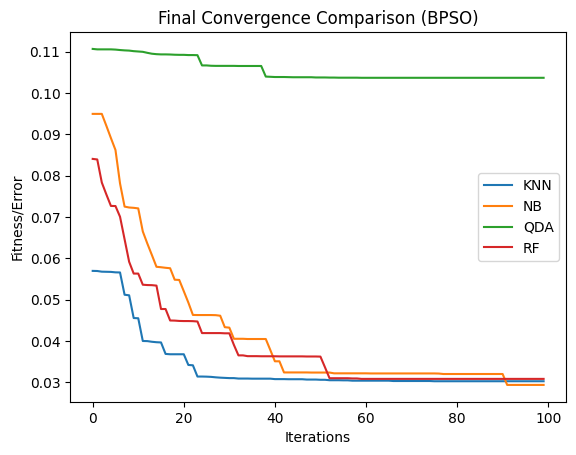


  SUMMARY  (averaged over 10 independent runs)

  --- Without Feature Selection ---
  Accuracy  : 83.88 %
  Precision : 0.8447
  Recall    : 0.8388
  F1-Score  : 0.8371

  Avg Execution Time : 25.6265 s
  Avg Memory Used    : 0.0033 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  85.00%   0.8532  0.8500 0.8510      10.1    72.70%
   NB  83.29%   0.8809  0.8329 0.8512       6.8    81.62%
  QDA  88.82%   0.8196  0.8882 0.8502       7.0    81.08%
   RF  86.84%   0.8560  0.8684 0.8598      12.2    67.03%


In [5]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ============================================================
# DATA LOADING & PREPROCESSING
# ============================================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-MW1.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
if 'id' in df.columns: df = df.drop(columns=['id'])

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

training_data = pd.DataFrame(X_train_scaled)
testing_data = pd.DataFrame(X_test_scaled)
training_label = y_train.reset_index(drop=True)
testing_label = y_test.reset_index(drop=True)

# ============================================================
# BPSO PARAMETERS
# ============================================================
NP = 10 
D = training_data.shape[1]
max_itr = 100
wmax = 0.9
wmin = 0.4
c1 = 2
c2 = 2
Vmax = D - 1
Vmin = -Vmax
alpha_weight = 0.99 

# ============================================================
# UTILITIES
# ============================================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def FitnessFunction(selected_indices, model_obj):
    if len(selected_indices) == 0:
        return 1.0
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        training_data.iloc[:, selected_indices], 
        training_label, 
        test_size=0.2, 
        random_state=42, 
        stratify=training_label
    )
    
    try:
        clf = clone(model_obj)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        error = 1 - accuracy_score(y_val, preds)
        feat_penalty = len(selected_indices) / D
        return alpha_weight * error + (1 - alpha_weight) * feat_penalty
    except:
        return 1.0

# ============================================================
# BPSO
# ============================================================
def BPSO_SFP(model_obj):
    X = np.random.randint(0, 2, (NP, D))
    V = np.random.uniform(Vmin, Vmax, (NP, D))
    fit = np.array([FitnessFunction(np.where(X[i] == 1)[0], model_obj) for i in range(NP)])
    pbest = X.copy()
    Pfit = fit.copy()
    gbest = X[np.argmin(fit)].copy()
    Gfit = np.min(fit)
    convergence_curve = []
    
    for epoch in range(max_itr):
        w = wmax - (wmax - wmin) * (epoch / max_itr)
        for i in range(NP):
            r1, r2 = random.random(), random.random()
            V[i] = (w * V[i] + c1 * r1 * (pbest[i] - X[i]) + c2 * r2 * (gbest - X[i]))
            V[i] = np.clip(V[i], Vmin, Vmax)
            for j in range(D):
                X[i, j] = 1 if sigmoid(V[i, j]) > random.random() else 0

            curr_idx = np.where(X[i] == 1)[0]
            curr_fit = FitnessFunction(curr_idx, model_obj)

            if curr_fit < Pfit[i]:
                pbest[i] = X[i].copy()
                Pfit[i] = curr_fit

            if Pfit[i] < Gfit:
                gbest = pbest[i].copy()
                Gfit = Pfit[i]

        convergence_curve.append(Gfit)

    return gbest, convergence_curve

# ============================================================
# MAIN LOOP
# ============================================================
models_dict = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS   = []
average_precision_without_FS  = []
average_recall_without_FS     = []
average_f1_without_FS         = []

for model_name, model_obj in models_dict.items():
    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []
    
    for r in range(1, 11): 
        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        best_mask, curve = BPSO_SFP(model_obj)
           
        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2
    
        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_mask == 1)[0]
        if len(Sf_idx) == 0: Sf_idx = np.array([np.random.randint(0, D)])
        
        clf = clone(model_obj)
        clf.fit(training_data.iloc[:, Sf_idx], training_label)
        pred = clf.predict(testing_data.iloc[:, Sf_idx])
        y_true = testing_label
        
        acc_list.append(accuracy_score(y_true, pred))
        prec_list.append(precision_score(y_true, pred, average='weighted', zero_division=0))
        rec_list.append(recall_score(y_true, pred, average='weighted', zero_division=0))
        f1_list.append(f1_score(y_true, pred, average='weighted', zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(curve)
        
        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f'Features selected :{Sf_idx} ')

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(training_data, training_label)
    pred_no_fs = clf_nofs.predict(testing_data)

    acc_no = accuracy_score(testing_label, pred_no_fs) * 100
    print(f"  Accuracy without FS: {acc_no:.2f} %")
    
    average_accuracy_without_FS.append(acc_no)
    average_precision_without_FS.append(precision_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(testing_label, pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (BPSO)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  --- Without Feature Selection ---")
print(f"  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.9057, Features=11
Features selected :[ 0  2  8 13 14 15 16 17 18 25 34] 
  Run 2: Acc=0.9245, Features=10
Features selected :[ 1  3  9 15 28 29 30 32 34 36] 
  Run 3: Acc=0.8962, Features=13
Features selected :[ 0  2  4  7 12 13 14 16 17 19 23 26 29] 
  Run 4: Acc=0.9057, Features=12
Features selected :[ 2  4 12 14 16 17 20 25 27 30 31 34] 
  Run 5: Acc=0.9104, Features=11
Features selected :[ 2  3  5  6  9 10 12 29 30 31 34] 
  Run 6: Acc=0.8821, Features=11
Features selected :[ 2  3  9 10 13 15 18 19 29 30 32] 
  Run 7: Acc=0.9104, Features=11
Features selected :[ 0  2  4  6 16 17 19 25 29 32 34] 
  Run 8: Acc=0.9009, Features=8
Features selected :[ 2  3  4  9 10 13 17 21] 
  Run 9: Acc=0.9104, Features=12
Features selected :[ 2  3  5  6  7  8  9 13 15 18 29 31] 
  Run 10: Acc=0.9057, Features=12
Features selected :[ 1  2  5  6 10 19 27 28 29 30 33 34] 
  Accuracy without FS: 89.62 %

Evaluating Model: NB
  Run 1: Acc=0.9104, Features=8
Features 

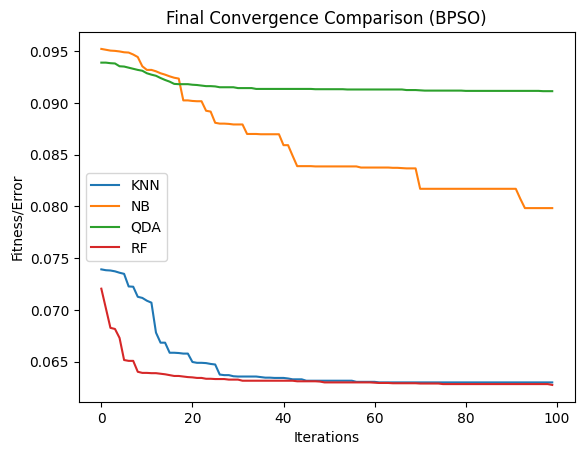


  SUMMARY  (averaged over 10 independent runs)

  --- Without Feature Selection ---
  Accuracy  : 90.80 %
  Precision : 0.8720
  Recall    : 0.9080
  F1-Score  : 0.8884

  Avg Execution Time : 26.2665 s
  Avg Memory Used    : 0.0201 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  90.52%   0.8594  0.9052 0.8773      11.1    70.00%
   NB  89.76%   0.8846  0.8976 0.8896       6.8    81.62%
  QDA  91.51%   0.8374  0.9151 0.8745       4.2    88.65%
   RF  91.18%   0.8873  0.9118 0.8927      10.2    72.43%


In [4]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ============================================================
# DATA LOADING & PREPROCESSING
# ============================================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-PC1.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
if 'id' in df.columns: df = df.drop(columns=['id'])

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

training_data = pd.DataFrame(X_train_scaled)
testing_data = pd.DataFrame(X_test_scaled)
training_label = y_train.reset_index(drop=True)
testing_label = y_test.reset_index(drop=True)

# ============================================================
# BPSO PARAMETERS
# ============================================================
NP = 10 
D = training_data.shape[1]
max_itr = 100
wmax = 0.9
wmin = 0.4
c1 = 2
c2 = 2
Vmax = D - 1
Vmin = -Vmax
alpha_weight = 0.99 

# ============================================================
# UTILITIES
# ============================================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def FitnessFunction(selected_indices, model_obj):
    if len(selected_indices) == 0:
        return 1.0
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        training_data.iloc[:, selected_indices], 
        training_label, 
        test_size=0.2, 
        random_state=42, 
        stratify=training_label
    )
    
    try:
        clf = clone(model_obj)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        error = 1 - accuracy_score(y_val, preds)
        feat_penalty = len(selected_indices) / D
        return alpha_weight * error + (1 - alpha_weight) * feat_penalty
    except:
        return 1.0

# ============================================================
# BPSO
# ============================================================
def BPSO_SFP(model_obj):
    X = np.random.randint(0, 2, (NP, D))
    V = np.random.uniform(Vmin, Vmax, (NP, D))
    fit = np.array([FitnessFunction(np.where(X[i] == 1)[0], model_obj) for i in range(NP)])
    pbest = X.copy()
    Pfit = fit.copy()
    gbest = X[np.argmin(fit)].copy()
    Gfit = np.min(fit)
    convergence_curve = []
    
    for epoch in range(max_itr):
        w = wmax - (wmax - wmin) * (epoch / max_itr)
        for i in range(NP):
            r1, r2 = random.random(), random.random()
            V[i] = (w * V[i] + c1 * r1 * (pbest[i] - X[i]) + c2 * r2 * (gbest - X[i]))
            V[i] = np.clip(V[i], Vmin, Vmax)
            for j in range(D):
                X[i, j] = 1 if sigmoid(V[i, j]) > random.random() else 0

            curr_idx = np.where(X[i] == 1)[0]
            curr_fit = FitnessFunction(curr_idx, model_obj)

            if curr_fit < Pfit[i]:
                pbest[i] = X[i].copy()
                Pfit[i] = curr_fit

            if Pfit[i] < Gfit:
                gbest = pbest[i].copy()
                Gfit = Pfit[i]

        convergence_curve.append(Gfit)

    return gbest, convergence_curve

# ============================================================
# MAIN LOOP
# ============================================================
models_dict = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS   = []
average_precision_without_FS  = []
average_recall_without_FS     = []
average_f1_without_FS         = []

for model_name, model_obj in models_dict.items():
    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []
    
    for r in range(1, 11): 
        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        best_mask, curve = BPSO_SFP(model_obj)
           
        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2
    
        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_mask == 1)[0]
        if len(Sf_idx) == 0: Sf_idx = np.array([np.random.randint(0, D)])
        
        clf = clone(model_obj)
        clf.fit(training_data.iloc[:, Sf_idx], training_label)
        pred = clf.predict(testing_data.iloc[:, Sf_idx])
        y_true = testing_label
        
        acc_list.append(accuracy_score(y_true, pred))
        prec_list.append(precision_score(y_true, pred, average='weighted', zero_division=0))
        rec_list.append(recall_score(y_true, pred, average='weighted', zero_division=0))
        f1_list.append(f1_score(y_true, pred, average='weighted', zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(curve)
        
        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f'Features selected :{Sf_idx} ')

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(training_data, training_label)
    pred_no_fs = clf_nofs.predict(testing_data)

    acc_no = accuracy_score(testing_label, pred_no_fs) * 100
    print(f"  Accuracy without FS: {acc_no:.2f} %")
    
    average_accuracy_without_FS.append(acc_no)
    average_precision_without_FS.append(precision_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(testing_label, pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (BPSO)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  --- Without Feature Selection ---")
print(f"  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.9732, Features=6
Features selected :[ 3  6 12 16 27 29] 
  Run 2: Acc=0.9777, Features=4
Features selected :[ 7 10 19 29] 
  Run 3: Acc=0.9777, Features=4
Features selected :[ 3 10 17 18] 
  Run 4: Acc=0.9777, Features=3
Features selected :[ 9 16 25] 
  Run 5: Acc=0.9732, Features=3
Features selected :[19 27 30] 
  Run 6: Acc=0.9777, Features=4
Features selected :[ 0  2 19 26] 
  Run 7: Acc=0.9777, Features=4
Features selected :[12 17 25 34] 
  Run 8: Acc=0.9777, Features=2
Features selected :[ 7 23] 
  Run 9: Acc=0.9777, Features=5
Features selected :[ 0  6  8  9 31] 
  Run 10: Acc=0.9777, Features=4
Features selected :[ 1 15 24 31] 
  Accuracy without FS: 97.77 %

Evaluating Model: NB
  Run 1: Acc=0.9777, Features=2
Features selected :[ 0 26] 
  Run 2: Acc=0.9732, Features=4
Features selected :[ 3  6  7 16] 
  Run 3: Acc=0.9286, Features=7
Features selected :[11 16 17 24 28 32 35] 
  Run 4: Acc=0.9732, Features=5
Features selected :[ 3  8 15 24 2

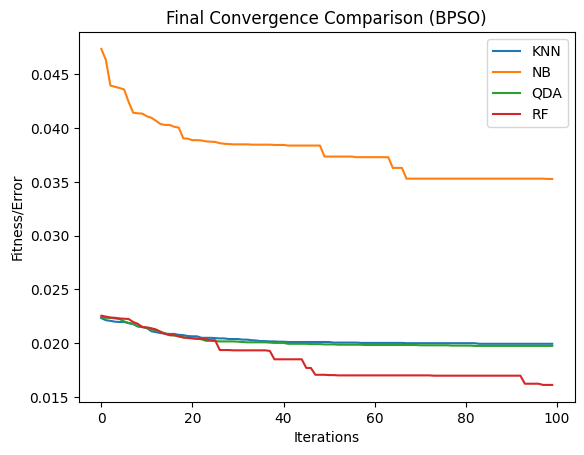


  SUMMARY  (averaged over 10 independent runs)

  --- Without Feature Selection ---
  Accuracy  : 96.32 %
  Precision : 0.9570
  Recall    : 0.9632
  F1-Score  : 0.9597

  Avg Execution Time : 26.3840 s
  Avg Memory Used    : 0.0018 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  97.68%   0.9558  0.9768 0.9662       3.9    89.17%
   NB  96.34%   0.9588  0.9634 0.9609       4.8    86.67%
  QDA  97.77%   0.9559  0.9777 0.9666       3.2    91.11%
   RF  97.50%   0.9558  0.9750 0.9653       7.1    80.28%


In [11]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ============================================================
# DATA LOADING & PREPROCESSING
# ============================================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-PC2.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
if 'id' in df.columns: df = df.drop(columns=['id'])

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

training_data = pd.DataFrame(X_train_scaled)
testing_data = pd.DataFrame(X_test_scaled)
training_label = y_train.reset_index(drop=True)
testing_label = y_test.reset_index(drop=True)

# ============================================================
# BPSO PARAMETERS
# ============================================================
NP = 10 
D = training_data.shape[1]
max_itr = 100
wmax = 0.9
wmin = 0.4
c1 = 2
c2 = 2
Vmax = D - 1
Vmin = -Vmax
alpha_weight = 0.99 

# ============================================================
# UTILITIES
# ============================================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def FitnessFunction(selected_indices, model_obj):
    if len(selected_indices) == 0:
        return 1.0
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        training_data.iloc[:, selected_indices], 
        training_label, 
        test_size=0.2, 
        random_state=42, 
        stratify=training_label
    )
    
    try:
        clf = clone(model_obj)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        error = 1 - accuracy_score(y_val, preds)
        feat_penalty = len(selected_indices) / D
        return alpha_weight * error + (1 - alpha_weight) * feat_penalty
    except:
        return 1.0

# ============================================================
# BPSO
# ============================================================
def BPSO_SFP(model_obj):
    X = np.random.randint(0, 2, (NP, D))
    V = np.random.uniform(Vmin, Vmax, (NP, D))
    fit = np.array([FitnessFunction(np.where(X[i] == 1)[0], model_obj) for i in range(NP)])
    pbest = X.copy()
    Pfit = fit.copy()
    gbest = X[np.argmin(fit)].copy()
    Gfit = np.min(fit)
    convergence_curve = []
    
    for epoch in range(max_itr):
        w = wmax - (wmax - wmin) * (epoch / max_itr)
        for i in range(NP):
            r1, r2 = random.random(), random.random()
            V[i] = (w * V[i] + c1 * r1 * (pbest[i] - X[i]) + c2 * r2 * (gbest - X[i]))
            V[i] = np.clip(V[i], Vmin, Vmax)
            for j in range(D):
                X[i, j] = 1 if sigmoid(V[i, j]) > random.random() else 0

            curr_idx = np.where(X[i] == 1)[0]
            curr_fit = FitnessFunction(curr_idx, model_obj)

            if curr_fit < Pfit[i]:
                pbest[i] = X[i].copy()
                Pfit[i] = curr_fit

            if Pfit[i] < Gfit:
                gbest = pbest[i].copy()
                Gfit = Pfit[i]

        convergence_curve.append(Gfit)

    return gbest, convergence_curve

# ============================================================
# MAIN LOOP
# ============================================================
models_dict = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS   = []
average_precision_without_FS  = []
average_recall_without_FS     = []
average_f1_without_FS         = []

for model_name, model_obj in models_dict.items():
    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []
    
    for r in range(1, 11): 
        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        best_mask, curve = BPSO_SFP(model_obj)
           
        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2
    
        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_mask == 1)[0]
        if len(Sf_idx) == 0: Sf_idx = np.array([np.random.randint(0, D)])
        
        clf = clone(model_obj)
        clf.fit(training_data.iloc[:, Sf_idx], training_label)
        pred = clf.predict(testing_data.iloc[:, Sf_idx])
        y_true = testing_label
        
        acc_list.append(accuracy_score(y_true, pred))
        prec_list.append(precision_score(y_true, pred, average='weighted', zero_division=0))
        rec_list.append(recall_score(y_true, pred, average='weighted', zero_division=0))
        f1_list.append(f1_score(y_true, pred, average='weighted', zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(curve)
        
        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f'Features selected :{Sf_idx} ')

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(training_data, training_label)
    pred_no_fs = clf_nofs.predict(testing_data)

    acc_no = accuracy_score(testing_label, pred_no_fs) * 100
    print(f"  Accuracy without FS: {acc_no:.2f} %")
    
    average_accuracy_without_FS.append(acc_no)
    average_precision_without_FS.append(precision_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(testing_label, pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (BPSO)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  --- Without Feature Selection ---")
print(f"  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.8704, Features=15
Features selected :[ 1  3  7 10 14 15 16 19 22 23 27 28 29 33 35] 
  Run 2: Acc=0.8673, Features=17
Features selected :[ 3  7  8 10 13 14 16 19 20 22 23 24 26 28 29 33 35] 
  Run 3: Acc=0.8735, Features=16
Features selected :[ 3  6  7  8 13 14 15 16 21 23 24 28 31 33 34 35] 
  Run 4: Acc=0.8735, Features=18
Features selected :[ 1  3  5 14 17 19 21 22 23 24 26 27 29 30 32 33 34 35] 
  Run 5: Acc=0.8765, Features=18
Features selected :[ 3  6  7 13 14 15 16 18 19 22 23 24 26 29 30 31 34 35] 
  Run 6: Acc=0.8704, Features=17
Features selected :[ 1  3  7 13 14 16 17 18 19 20 23 26 27 31 34 35 36] 
  Run 7: Acc=0.8673, Features=17
Features selected :[ 1  3  5  7  8 12 13 16 17 18 19 20 24 28 29 30 34] 
  Run 8: Acc=0.8673, Features=15
Features selected :[ 3 11 12 14 15 16 17 18 19 22 30 31 32 33 34] 
  Run 9: Acc=0.8704, Features=15
Features selected :[ 1  3  7  8 12 13 14 16 18 23 30 31 32 34 35] 
  Run 10: Acc=0.8735, Features=16
Feat

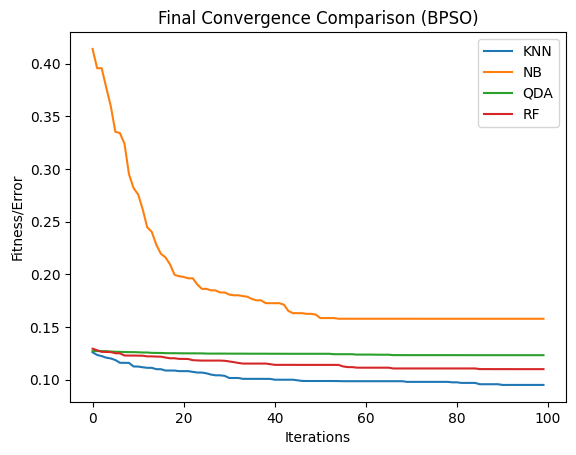


  SUMMARY  (averaged over 10 independent runs)

  --- Without Feature Selection ---
  Accuracy  : 72.92 %
  Precision : 0.8457
  Recall    : 0.7292
  F1-Score  : 0.7068

  Avg Execution Time : 30.9308 s
  Avg Memory Used    : 0.0271 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  87.10%   0.8182  0.8710 0.8294      16.4    55.68%
   NB  86.11%   0.8365  0.8611 0.8432       6.3    82.97%
  QDA  87.65%   0.7683  0.8765 0.8189       9.3    74.86%
   RF  86.85%   0.8209  0.8685 0.8318      13.6    63.24%


In [7]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ============================================================
# DATA LOADING & PREPROCESSING
# ============================================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-PC3.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
if 'id' in df.columns: df = df.drop(columns=['id'])

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

training_data = pd.DataFrame(X_train_scaled)
testing_data = pd.DataFrame(X_test_scaled)
training_label = y_train.reset_index(drop=True)
testing_label = y_test.reset_index(drop=True)

# ============================================================
# BPSO PARAMETERS
# ============================================================
NP = 10 
D = training_data.shape[1]
max_itr = 100
wmax = 0.9
wmin = 0.4
c1 = 2
c2 = 2
Vmax = D - 1
Vmin = -Vmax
alpha_weight = 0.99 

# ============================================================
# UTILITIES
# ============================================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def FitnessFunction(selected_indices, model_obj):
    if len(selected_indices) == 0:
        return 1.0
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        training_data.iloc[:, selected_indices], 
        training_label, 
        test_size=0.2, 
        random_state=42, 
        stratify=training_label
    )
    
    try:
        clf = clone(model_obj)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        error = 1 - accuracy_score(y_val, preds)
        feat_penalty = len(selected_indices) / D
        return alpha_weight * error + (1 - alpha_weight) * feat_penalty
    except:
        return 1.0

# ============================================================
# BPSO
# ============================================================
def BPSO_SFP(model_obj):
    X = np.random.randint(0, 2, (NP, D))
    V = np.random.uniform(Vmin, Vmax, (NP, D))
    fit = np.array([FitnessFunction(np.where(X[i] == 1)[0], model_obj) for i in range(NP)])
    pbest = X.copy()
    Pfit = fit.copy()
    gbest = X[np.argmin(fit)].copy()
    Gfit = np.min(fit)
    convergence_curve = []
    
    for epoch in range(max_itr):
        w = wmax - (wmax - wmin) * (epoch / max_itr)
        for i in range(NP):
            r1, r2 = random.random(), random.random()
            V[i] = (w * V[i] + c1 * r1 * (pbest[i] - X[i]) + c2 * r2 * (gbest - X[i]))
            V[i] = np.clip(V[i], Vmin, Vmax)
            for j in range(D):
                X[i, j] = 1 if sigmoid(V[i, j]) > random.random() else 0

            curr_idx = np.where(X[i] == 1)[0]
            curr_fit = FitnessFunction(curr_idx, model_obj)

            if curr_fit < Pfit[i]:
                pbest[i] = X[i].copy()
                Pfit[i] = curr_fit

            if Pfit[i] < Gfit:
                gbest = pbest[i].copy()
                Gfit = Pfit[i]

        convergence_curve.append(Gfit)

    return gbest, convergence_curve

# ============================================================
# MAIN LOOP
# ============================================================
models_dict = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS   = []
average_precision_without_FS  = []
average_recall_without_FS     = []
average_f1_without_FS         = []

for model_name, model_obj in models_dict.items():
    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []
    
    for r in range(1, 11): 
        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        best_mask, curve = BPSO_SFP(model_obj)
           
        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2
    
        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_mask == 1)[0]
        if len(Sf_idx) == 0: Sf_idx = np.array([np.random.randint(0, D)])
        
        clf = clone(model_obj)
        clf.fit(training_data.iloc[:, Sf_idx], training_label)
        pred = clf.predict(testing_data.iloc[:, Sf_idx])
        y_true = testing_label
        
        acc_list.append(accuracy_score(y_true, pred))
        prec_list.append(precision_score(y_true, pred, average='weighted', zero_division=0))
        rec_list.append(recall_score(y_true, pred, average='weighted', zero_division=0))
        f1_list.append(f1_score(y_true, pred, average='weighted', zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(curve)
        
        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f'Features selected :{Sf_idx} ')

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(training_data, training_label)
    pred_no_fs = clf_nofs.predict(testing_data)

    acc_no = accuracy_score(testing_label, pred_no_fs) * 100
    print(f"  Accuracy without FS: {acc_no:.2f} %")
    
    average_accuracy_without_FS.append(acc_no)
    average_precision_without_FS.append(precision_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(testing_label, pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (BPSO)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  --- Without Feature Selection ---")
print(f"  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.8941, Features=15
Features selected :[ 0  3  5  8  9 12 13 15 17 19 22 29 33 34 36] 
  Run 2: Acc=0.8734, Features=14
Features selected :[ 2  3  5  6 13 14 15 17 20 21 23 26 30 33] 
  Run 3: Acc=0.8760, Features=15
Features selected :[ 2  3  5  7  9 19 20 21 22 23 28 29 31 32 36] 
  Run 4: Acc=0.8682, Features=18
Features selected :[ 1  3  5  7 11 12 13 15 20 22 23 28 30 31 32 33 34 36] 
  Run 5: Acc=0.8708, Features=21
Features selected :[ 0  2  3  4  7  9 10 12 14 15 16 18 21 22 26 27 28 30 31 34 35] 
  Run 6: Acc=0.8708, Features=13
Features selected :[ 1  3  7 10 11 12 15 19 21 23 24 32 33] 
  Run 7: Acc=0.8708, Features=15
Features selected :[ 1  3  7 10 11 15 17 19 20 23 26 29 31 33 34] 
  Run 8: Acc=0.8734, Features=12
Features selected :[ 3  6  8 11 12 16 17 19 21 22 28 33] 
  Run 9: Acc=0.8579, Features=15
Features selected :[ 1  3  5  6 10 11 13 15 20 24 29 30 31 33 36] 
  Run 10: Acc=0.8734, Features=11
Features selected :[ 3  5  6 17 19

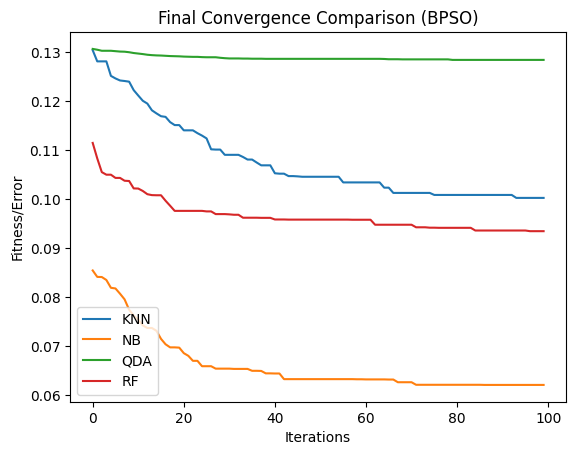


  SUMMARY  (averaged over 10 independent runs)

  --- Without Feature Selection ---
  Accuracy  : 87.08 %
  Precision : 0.8454
  Recall    : 0.8708
  F1-Score  : 0.8464

  Avg Execution Time : 30.3608 s
  Avg Memory Used    : 0.0160 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  87.29%   0.8529  0.8729 0.8568      14.9    59.73%
   NB  87.31%   0.8651  0.8731 0.8678      18.0    51.35%
  QDA  86.33%   0.8297  0.8633 0.8041       7.3    80.27%
   RF  89.38%   0.8819  0.8938 0.8814      16.2    56.22%


In [8]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ============================================================
# DATA LOADING & PREPROCESSING
# ============================================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-PC4.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
if 'id' in df.columns: df = df.drop(columns=['id'])

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

training_data = pd.DataFrame(X_train_scaled)
testing_data = pd.DataFrame(X_test_scaled)
training_label = y_train.reset_index(drop=True)
testing_label = y_test.reset_index(drop=True)

# ============================================================
# BPSO PARAMETERS
# ============================================================
NP = 10 
D = training_data.shape[1]
max_itr = 100
wmax = 0.9
wmin = 0.4
c1 = 2
c2 = 2
Vmax = D - 1
Vmin = -Vmax
alpha_weight = 0.99 

# ============================================================
# UTILITIES
# ============================================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def FitnessFunction(selected_indices, model_obj):
    if len(selected_indices) == 0:
        return 1.0
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        training_data.iloc[:, selected_indices], 
        training_label, 
        test_size=0.2, 
        random_state=42, 
        stratify=training_label
    )
    
    try:
        clf = clone(model_obj)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        error = 1 - accuracy_score(y_val, preds)
        feat_penalty = len(selected_indices) / D
        return alpha_weight * error + (1 - alpha_weight) * feat_penalty
    except:
        return 1.0

# ============================================================
# BPSO
# ============================================================
def BPSO_SFP(model_obj):
    X = np.random.randint(0, 2, (NP, D))
    V = np.random.uniform(Vmin, Vmax, (NP, D))
    fit = np.array([FitnessFunction(np.where(X[i] == 1)[0], model_obj) for i in range(NP)])
    pbest = X.copy()
    Pfit = fit.copy()
    gbest = X[np.argmin(fit)].copy()
    Gfit = np.min(fit)
    convergence_curve = []
    
    for epoch in range(max_itr):
        w = wmax - (wmax - wmin) * (epoch / max_itr)
        for i in range(NP):
            r1, r2 = random.random(), random.random()
            V[i] = (w * V[i] + c1 * r1 * (pbest[i] - X[i]) + c2 * r2 * (gbest - X[i]))
            V[i] = np.clip(V[i], Vmin, Vmax)
            for j in range(D):
                X[i, j] = 1 if sigmoid(V[i, j]) > random.random() else 0

            curr_idx = np.where(X[i] == 1)[0]
            curr_fit = FitnessFunction(curr_idx, model_obj)

            if curr_fit < Pfit[i]:
                pbest[i] = X[i].copy()
                Pfit[i] = curr_fit

            if Pfit[i] < Gfit:
                gbest = pbest[i].copy()
                Gfit = Pfit[i]

        convergence_curve.append(Gfit)

    return gbest, convergence_curve

# ============================================================
# MAIN LOOP
# ============================================================
models_dict = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS   = []
average_precision_without_FS  = []
average_recall_without_FS     = []
average_f1_without_FS         = []

for model_name, model_obj in models_dict.items():
    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []
    
    for r in range(1, 11): 
        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        best_mask, curve = BPSO_SFP(model_obj)
           
        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2
    
        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_mask == 1)[0]
        if len(Sf_idx) == 0: Sf_idx = np.array([np.random.randint(0, D)])
        
        clf = clone(model_obj)
        clf.fit(training_data.iloc[:, Sf_idx], training_label)
        pred = clf.predict(testing_data.iloc[:, Sf_idx])
        y_true = testing_label
        
        acc_list.append(accuracy_score(y_true, pred))
        prec_list.append(precision_score(y_true, pred, average='weighted', zero_division=0))
        rec_list.append(recall_score(y_true, pred, average='weighted', zero_division=0))
        f1_list.append(f1_score(y_true, pred, average='weighted', zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(curve)
        
        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f'Features selected :{Sf_idx} ')

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(training_data, training_label)
    pred_no_fs = clf_nofs.predict(testing_data)

    acc_no = accuracy_score(testing_label, pred_no_fs) * 100
    print(f"  Accuracy without FS: {acc_no:.2f} %")
    
    average_accuracy_without_FS.append(acc_no)
    average_precision_without_FS.append(precision_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(testing_label, pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (BPSO)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  --- Without Feature Selection ---")
print(f"  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.7412, Features=19
Features selected :[ 2  3  4  5  7  9 11 12 14 15 16 17 21 28 30 32 33 34 37] 
  Run 2: Acc=0.7471, Features=16
Features selected :[ 1  6  8  9 11 12 16 17 21 22 23 24 25 26 34 37] 
  Run 3: Acc=0.7685, Features=18
Features selected :[ 3  4  6  9 11 14 16 17 20 22 23 24 26 27 29 32 34 35] 
  Run 4: Acc=0.7588, Features=16
Features selected :[ 3  4  5  9 11 13 15 16 17 18 21 23 26 29 34 37] 
  Run 5: Acc=0.7451, Features=21
Features selected :[ 2  3  4  5  6  7  9 11 12 15 16 17 19 23 24 25 30 31 32 34 37] 
  Run 6: Acc=0.7490, Features=24
Features selected :[ 0  3  6  8  9 11 13 14 16 17 18 20 21 22 23 24 26 27 29 31 32 33 34 35] 
  Run 7: Acc=0.7529, Features=23
Features selected :[ 1  3  4  6  9 11 12 13 14 15 17 18 22 23 24 26 29 30 31 33 34 35 37] 
  Run 8: Acc=0.7490, Features=22
Features selected :[ 0  1  2  3  5  6  7  9 12 15 16 17 18 19 21 25 28 30 33 34 35 37] 
  Run 9: Acc=0.7432, Features=16
Features selected :[ 3  4 1

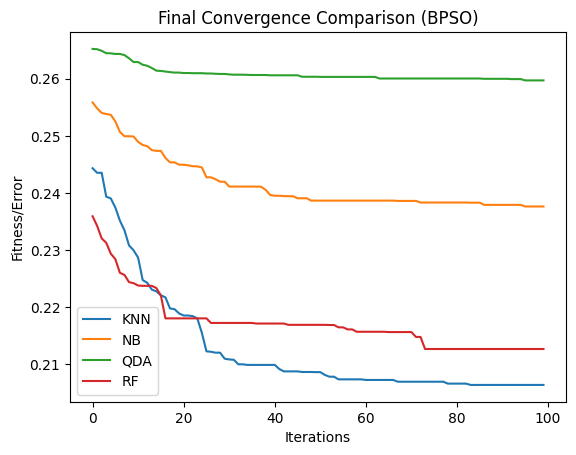


  SUMMARY  (averaged over 10 independent runs)

  --- Without Feature Selection ---
  Accuracy  : 74.71 %
  Precision : 0.7234
  Recall    : 0.7471
  F1-Score  : 0.7090

  Avg Execution Time : 31.7125 s
  Avg Memory Used    : 0.0496 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  74.92%   0.7326  0.7492 0.7368      19.4    48.95%
   NB  73.66%   0.7032  0.7366 0.6951      11.1    70.79%
  QDA  73.25%   0.7189  0.7325 0.6386      10.3    72.89%
   RF  76.96%   0.7526  0.7696 0.7520      18.2    52.11%


In [9]:
# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# ============================================================
# DATA LOADING & PREPROCESSING
# ============================================================
df = pd.read_csv('/kaggle/input/datasets/samundefined/sfp-dataset/csv_result-PC5.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
if 'id' in df.columns: df = df.drop(columns=['id'])

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x == 'Y' or x == 1 or x == True else 0)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

training_data = pd.DataFrame(X_train_scaled)
testing_data = pd.DataFrame(X_test_scaled)
training_label = y_train.reset_index(drop=True)
testing_label = y_test.reset_index(drop=True)

# ============================================================
# BPSO PARAMETERS
# ============================================================
NP = 10 
D = training_data.shape[1]
max_itr = 100
wmax = 0.9
wmin = 0.4
c1 = 2
c2 = 2
Vmax = D - 1
Vmin = -Vmax
alpha_weight = 0.99 

# ============================================================
# UTILITIES
# ============================================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def FitnessFunction(selected_indices, model_obj):
    if len(selected_indices) == 0:
        return 1.0
    
    X_tr, X_val, y_tr, y_val = train_test_split(
        training_data.iloc[:, selected_indices], 
        training_label, 
        test_size=0.2, 
        random_state=42, 
        stratify=training_label
    )
    
    try:
        clf = clone(model_obj)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_val)
        error = 1 - accuracy_score(y_val, preds)
        feat_penalty = len(selected_indices) / D
        return alpha_weight * error + (1 - alpha_weight) * feat_penalty
    except:
        return 1.0

# ============================================================
# BPSO
# ============================================================
def BPSO_SFP(model_obj):
    X = np.random.randint(0, 2, (NP, D))
    V = np.random.uniform(Vmin, Vmax, (NP, D))
    fit = np.array([FitnessFunction(np.where(X[i] == 1)[0], model_obj) for i in range(NP)])
    pbest = X.copy()
    Pfit = fit.copy()
    gbest = X[np.argmin(fit)].copy()
    Gfit = np.min(fit)
    convergence_curve = []
    
    for epoch in range(max_itr):
        w = wmax - (wmax - wmin) * (epoch / max_itr)
        for i in range(NP):
            r1, r2 = random.random(), random.random()
            V[i] = (w * V[i] + c1 * r1 * (pbest[i] - X[i]) + c2 * r2 * (gbest - X[i]))
            V[i] = np.clip(V[i], Vmin, Vmax)
            for j in range(D):
                X[i, j] = 1 if sigmoid(V[i, j]) > random.random() else 0

            curr_idx = np.where(X[i] == 1)[0]
            curr_fit = FitnessFunction(curr_idx, model_obj)

            if curr_fit < Pfit[i]:
                pbest[i] = X[i].copy()
                Pfit[i] = curr_fit

            if Pfit[i] < Gfit:
                gbest = pbest[i].copy()
                Gfit = Pfit[i]

        convergence_curve.append(Gfit)

    return gbest, convergence_curve

# ============================================================
# MAIN LOOP
# ============================================================
models_dict = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20, n_jobs=-1)
}

model_summaries = []
Total_time = []
Total_memory = []

average_accuracy_without_FS   = []
average_precision_without_FS  = []
average_recall_without_FS     = []
average_f1_without_FS         = []

for model_name, model_obj in models_dict.items():
    print(f"\nEvaluating Model: {model_name}")
    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []
    
    for r in range(1, 11): 
        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024 ** 2
        st = time.time()

        best_mask, curve = BPSO_SFP(model_obj)
           
        et = time.time()
        mem_after = process.memory_info().rss / 1024 ** 2
    
        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        Sf_idx = np.where(best_mask == 1)[0]
        if len(Sf_idx) == 0: Sf_idx = np.array([np.random.randint(0, D)])
        
        clf = clone(model_obj)
        clf.fit(training_data.iloc[:, Sf_idx], training_label)
        pred = clf.predict(testing_data.iloc[:, Sf_idx])
        y_true = testing_label
        
        acc_list.append(accuracy_score(y_true, pred))
        prec_list.append(precision_score(y_true, pred, average='weighted', zero_division=0))
        rec_list.append(recall_score(y_true, pred, average='weighted', zero_division=0))
        f1_list.append(f1_score(y_true, pred, average='weighted', zero_division=0))
        feat_list.append(len(Sf_idx))
        curves.append(curve)
        
        print(f"  Run {r}: Acc={acc_list[-1]:.4f}, Features={len(Sf_idx)}")
        print(f'Features selected :{Sf_idx} ')

    # 🔥 STORE CURVE
    model_curves[model_name] = np.mean(curves, axis=0)

    model_summaries.append({
        "Model": model_name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

    # WITHOUT FS
    clf_nofs = clone(model_obj)
    clf_nofs.fit(training_data, training_label)
    pred_no_fs = clf_nofs.predict(testing_data)

    acc_no = accuracy_score(testing_label, pred_no_fs) * 100
    print(f"  Accuracy without FS: {acc_no:.2f} %")
    
    average_accuracy_without_FS.append(acc_no)
    average_precision_without_FS.append(precision_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_recall_without_FS.append(recall_score(testing_label, pred_no_fs, average='weighted', zero_division=0))
    average_f1_without_FS.append(f1_score(testing_label, pred_no_fs, average='weighted', zero_division=0))

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (BPSO)")
plt.xlabel("Iterations")
plt.ylabel("Fitness/Error")
plt.legend()
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*55)
print("  SUMMARY  (averaged over 10 independent runs)")
print("="*55)

print(f"\n  --- Without Feature Selection ---")
print(f"  Accuracy  : {np.mean(average_accuracy_without_FS):.2f} %")
print(f"  Precision : {np.mean(average_precision_without_FS):.4f}")
print(f"  Recall    : {np.mean(average_recall_without_FS):.4f}")
print(f"  F1-Score  : {np.mean(average_f1_without_FS):.4f}")

print(f"\n  Avg Execution Time : {np.mean(Total_time):.4f} s")
print(f"  Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)